# Task 5: Classification Tasks

### Importing Required Libraries
#### The following libraries are essential for data manipulation, visualization, preprocessing, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

#### Download necessary datasets for NLP processing

In [2]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\charitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\charitha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### Task 1: Student Pass/Fail Prediction

#### Student Pass/Fail Prediction: Predicting student performance based on study hours and attendance.

In [3]:
def student_prediction():
    # Generate sample data
    np.random.seed(42)
    data = pd.DataFrame({
        'Study_Hours': np.random.randint(1, 20, 100),
        'Attendance': np.random.randint(50, 100, 100),
    })
    data['Pass'] = (data['Study_Hours'] * 0.5 + data['Attendance'] * 0.3 > 25).astype(int)
    
    # EDA
    print("Data Head:\n", data.head())
    print("Missing Values:\n", data.isnull().sum())
    sns.pairplot(data, hue='Pass')
    plt.show()
    
    # Train-Test Split
    X = data[['Study_Hours', 'Attendance']]
    y = data['Pass']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Model Training
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

### Task 2: Sentiment Analysis

#### Sentiment Analysis: Classifying customer reviews as positive or negative.

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return " ".join(tokens)

def sentiment_analysis():
    # Sample Dataset
    reviews = {'Review': ["I love this product!", "Worst experience ever.", "Not bad, could be better.",
                          "Amazing quality!", "Terrible service, will never buy again."],
               'Sentiment': ['positive', 'negative', 'positive', 'positive', 'negative']}
    df = pd.DataFrame(reviews)
    
    # Text Preprocessing
    df['Processed_Review'] = df['Review'].apply(preprocess_text)
    
    # Vectorization (TF-IDF)
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(df['Processed_Review'])
    y = df['Sentiment'].map({'positive': 1, 'negative': 0})
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Model Training
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

#### Executing Both Tasks  

Task 1: Student Pass/Fail Prediction
Data Head:
    Study_Hours  Attendance  Pass
0            7          71     0
1           15          76     1
2           11          84     1
3            8          50     0
4            7          84     1
Missing Values:
 Study_Hours    0
Attendance     0
Pass           0
dtype: int64


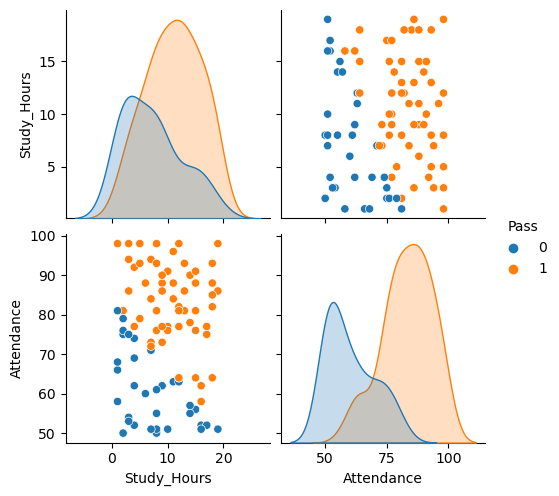

Accuracy: 1.0
Confusion Matrix:
 [[ 5  0]
 [ 0 15]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        15

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Task 2: Sentiment Analysis
Accuracy: 0.0
Confusion Matrix:
 [[0 1]
 [0 0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\charitha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\charitha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\charitha\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\charitha\anaconda3\lib\site-packages\sklearn\

In [5]:
if __name__ == "__main__":
    print("Task 1: Student Pass/Fail Prediction")
    student_prediction()
    print("\nTask 2: Sentiment Analysis")
    sentiment_analysis()